#Imports and Set-Up

In [242]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker
from scipy import stats

import warnings
warnings.filterwarnings('ignore')

#For neat plots
sns.set_theme(style = "whitegrid", palette = "muted")
plt.rcParams.update({'figure.dpi' : 130, 'axes.titlesize':13,
                     'axes.labelsize':11,
                     'xtick.labelsize': 9,'ytick.labelsize': 9,})

fearcolor = "#E33724"
greedcolor = "#18BE5D"

palette = {'Fear': fearcolor, 'Greed': greedcolor}


#**Part A: Data Preparation**

In [243]:
feargreed_path = '/content/fear_greed_index.csv'
historicaldata_path = '/content/historical_data.csv'

trades_raw    = pd.read_csv(historicaldata_path)
sentiment_raw = pd.read_csv(feargreed_path)

print(f"trades: {trades_raw.shape[0]:,} rows x {trades_raw.shape[1]} cols")
print(f"sentiment: {sentiment_raw.shape[0]:,} rows x {sentiment_raw.shape[1]} cols")

trades: 211,224 rows x 16 cols
sentiment: 2,644 rows x 4 cols


##Structure of trades data

In [244]:
trades_raw.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [245]:
trades_raw.dtypes

,0
Account,object
Coin,object
Execution Price,float64
Size Tokens,float64
Size USD,float64
Side,object
Timestamp IST,object
Start Position,float64
Direction,object
Closed PnL,float64


In [246]:
missing_values = trades_raw.isnull().sum()[trades_raw.isnull().sum() > 0]
print("missing values in trades raw data:")
display(missing_values)

missing values in trades raw data:


,0


##Structure of sentiment data

In [247]:
sentiment_raw.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [248]:
sentiment_raw.dtypes

,0
timestamp,int64
value,int64
classification,object
date,object


In [249]:
missing_values = sentiment_raw.isnull().sum()
print("missing values in sentiment raw data:")
display(missing_values)

missing values in sentiment raw data:


,0
timestamp,0
value,0
classification,0
date,0


##Formatting Column and adjusting Date Column

In [250]:
trades_raw.columns = (
    trades_raw.columns
    .str.strip()
    .str.lower()
    .str.replace(r'[\s/]+', '_', regex=True)
    .str.replace(r'[^a-z0-9_]', '', regex=True)
)


sentiment_raw.columns = (
    sentiment_raw.columns
    .str.strip()
    .str.lower()
    .str.replace(r'[\s/]+', '_', regex=True)
    .str.replace(r'[^a-z0-9_]', '', regex=True)
)

print('Trades cols   :', list(trades_raw.columns))
print('Sentiment cols:', list(sentiment_raw.columns))

Trades cols   : ['account', 'coin', 'execution_price', 'size_tokens', 'size_usd', 'side', 'timestamp_ist', 'start_position', 'direction', 'closed_pnl', 'transaction_hash', 'order_id', 'crossed', 'fee', 'trade_id', 'timestamp']
Sentiment cols: ['timestamp', 'value', 'classification', 'date']


In [251]:
#Adjusting and standardizing timestamp and date columns

TIMESTAMP_COL = [c for c in trades_raw.columns if 'time' in c][0]
print(f'Using timestamp column: "{TIMESTAMP_COL}"')
print('Sample values:', trades_raw[TIMESTAMP_COL].head(3).tolist())

trades_raw['datetime'] = pd.to_datetime(
    trades_raw[TIMESTAMP_COL],
    format='%d-%m-%Y %H:%M',   # ← explicit format
    errors='coerce'
)

# trades_raw['datetime'] = pd.to_datetime(
#     trades_raw[TIMESTAMP_COL],
#     infer_datetime_format=True,
#     errors='coerce'
# )
trades_raw['date'] = trades_raw['datetime'].dt.normalize()   # midnight UTC

bad_ts = trades_raw['datetime'].isna().sum()
print(f'\nUnparseable timestamps: {bad_ts}')
if bad_ts:
    print(trades_raw[trades_raw['datetime'].isna()][TIMESTAMP_COL].value_counts().head())

trades_raw = trades_raw.dropna(subset=['datetime'])  # drop rows with bad timestamps
print(f'Rows after dropping bad timestamps: {len(trades_raw):,}')

#No bad timestamps, all rows retained

Using timestamp column: "timestamp_ist"
Sample values: ['02-12-2024 22:50', '02-12-2024 22:50', '02-12-2024 22:50']

Unparseable timestamps: 0
Rows after dropping bad timestamps: 211,224


In [252]:
#Adjusting and standardizing timestamp and date columns of Sentiment Table

DATE_COL_S = 'date' if 'date' in sentiment_raw.columns else 'timestamp'
print(f'Using sentiment date column: "{DATE_COL_S}"')
print('Sample values:', sentiment_raw[DATE_COL_S].head(3).tolist())

sentiment_raw['date'] = pd.to_datetime(
    sentiment_raw[DATE_COL_S],
    infer_datetime_format=True,
    errors='coerce'
).dt.normalize()

print(f'\nSentiment date range: {sentiment_raw["date"].min().date()} -> {sentiment_raw["date"].max().date()}')

Using sentiment date column: "date"
Sample values: ['2018-02-01', '2018-02-02', '2018-02-03']

Sentiment date range: 2018-02-01 -> 2025-05-02


##Simplification of trades_raw classification column

In [253]:
# Discretization of classification column - mapping extreme greed/fear to greed/fear

CLASS_COL = 'classification'
sentiment_raw[CLASS_COL] = (
    sentiment_raw[CLASS_COL]
    .str.strip()
    .str.title()
    .replace({
        'Extreme Fear' : 'Fear',
        'Extreme Greed': 'Greed',
        'Neutral'      : 'Neutral',   # keep neutral separately
    })
)

print('Sentiment label distribution:')
display(sentiment_raw[CLASS_COL].value_counts())

Sentiment label distribution:


,count
classification,
Fear,1289
Greed,959
Neutral,396


##De-duplication

In [254]:
# Trades — identify potential duplicate key
TRADE_ID_COL = [c for c in trades_raw.columns if 'trade_id' in c or 'hash' in c]
print('Candidate deduplicate columns (trades):', TRADE_ID_COL)

before = len(trades_raw)
if TRADE_ID_COL:
    trades_raw = trades_raw.drop_duplicates(subset=TRADE_ID_COL[0])
else:
    trades_raw = trades_raw.drop_duplicates()
print(f'Trades deduplicates: {before:,} → {len(trades_raw):,} rows (removed {before - len(trades_raw):,})')


print("\nSentiment Data:")
# number of duplicate rows based on date
dup_count = sentiment_raw.duplicated(subset=['date']).sum()
print("Duplicate rows (by date):", dup_count)

# number of unique dates
unique_dates = sentiment_raw['date'].nunique()
print("Unique dates:", unique_dates)

before_s = len(sentiment_raw)
sentiment_raw = sentiment_raw.drop_duplicates(subset=['date'])
print(f'Sentiment deduplicates: {before_s} → {len(sentiment_raw)} rows')

Candidate deduplicate columns (trades): ['transaction_hash', 'trade_id']
Trades deduplicates: 211,224 → 101,184 rows (removed 110,040)

Sentiment Data:
Duplicate rows (by date): 0
Unique dates: 2644
Sentiment deduplicates: 2644 → 2644 rows


##Standardizing and cleaning numeric attribute types

In [255]:
#First identifying numeric type

ACCOUNT_COL    = [c for c in trades_raw.columns if 'account' in c][0]
SIDE_COL       = [c for c in trades_raw.columns if 'side' in c][0]
PNL_COL        = [c for c in trades_raw.columns if 'pnl' in c or 'closedpnl' in c][0]
SIZE_USD_COL   = [c for c in trades_raw.columns if 'size_usd' in c or 'sizeusd' in c or ('size' in c and 'usd' in c)]
SIZE_USD_COL   = SIZE_USD_COL[0] if SIZE_USD_COL else None    #may be null or zero (or not exist) if the dataset provides the trade size in tokens of crypto currency or non usd equivalent
LEVERAGE_COL   = [c for c in trades_raw.columns if 'leverage' in c]
LEVERAGE_COL   = LEVERAGE_COL[0] if LEVERAGE_COL else None  # may be null or zero (or not exist) if the trading platform doesn't record leverage data (like spot traders have no leverage and hyperliquid data might omit it)
EXEC_PRICE_COL = [c for c in trades_raw.columns if 'execution' in c or 'price' in c][0]
SIZE_TOKEN_COL = [c for c in trades_raw.columns if 'size' in c and 'token' in c]
SIZE_TOKEN_COL = SIZE_TOKEN_COL[0] if SIZE_TOKEN_COL else None

print(f'account    : {ACCOUNT_COL}')
print(f'side       : {SIDE_COL}')
print(f'pnl        : {PNL_COL}')
print(f'size_usd   : {SIZE_USD_COL}')
print(f'leverage   : {LEVERAGE_COL}')
print(f'exec_price : {EXEC_PRICE_COL}')

# Coerce to numeric
num_cols = [c for c in [PNL_COL, SIZE_USD_COL, LEVERAGE_COL, EXEC_PRICE_COL, SIZE_TOKEN_COL] if c]
for col in num_cols:
    trades_raw[col] = pd.to_numeric(trades_raw[col], errors='coerce')

# Standardise side to UPPER
trades_raw[SIDE_COL] = trades_raw[SIDE_COL].str.strip().str.upper()

print('\n\nNumeric stats for key columns:')
display(trades_raw[num_cols].describe())

account    : account
side       : side
pnl        : closed_pnl
size_usd   : size_usd
leverage   : None
exec_price : execution_price


Numeric stats for key columns:


,closed_pnl,size_usd,execution_price,size_tokens
count,101184.000000,1.011840e+05,101184.000000,1.011840e+05
mean,56.954723,4.242173e+03,9926.197766,6.943248e+03
std,1101.825807,3.977517e+04,27796.209593,1.377028e+05
min,-117990.104100,0.000000e+00,0.000005,1.000000e-05
25%,0.000000,1.651475e+02,1.449000,3.330000e+00
50%,0.000000,5.261800e+02,16.818000,3.742000e+01
75%,4.032548,1.581787e+03,106.370000,3.044500e+02
max,135329.090100,3.921431e+06,109004.000000,1.582244e+07


##Merge sentiment and trades data on date

In [256]:
sentiment_slim = sentiment_raw[['date', CLASS_COL]].rename(columns={CLASS_COL: 'sentiment'})
#strips the sentiment table down to just two columns — date and classification — and renames classification to sentiment for cleaner column naming downstream.
trades = trades_raw.merge(sentiment_slim, on='date', how='left')  #left - ensures all trade rows are kept even if a matching sentiment date doesn't exist

unmatched = trades['sentiment'].isna().sum()
print(f'Total trade rows        : {len(trades):,}')
print(f'Rows with sentiment data: {(~trades["sentiment"].isna()).sum():,}')
print(f'Rows WITHOUT sentiment  : {unmatched:,}  ({100*unmatched/len(trades):.4f}%)')

#drop rows without a sentiment label for the main analysis
trades_m = trades.dropna(subset=['sentiment']).copy() #those unmatched rows just get NaN for sentiment and are dropped
print(f'\nWorking dataset size: {len(trades_m):,} rows')

Total trade rows        : 101,184
Rows with sentiment data: 101,181
Rows WITHOUT sentiment  : 3  (0.0030%)

Working dataset size: 101,181 rows


##Feature Creation (Key Metrics Engineering)

###1. Trade Type Flags

In [257]:
#Trade Type Flags

#flags trades that closed a position - if PnL is non-null or non-zero (as open trades have 0 or null PnL)
trades_m['is_close']    = trades_m[PNL_COL].notna() & (trades_m[PNL_COL] != 0)

#if PnL is positive then the trade is marked as profitable
trades_m['is_win']      = trades_m[PNL_COL] > 0

#if the trade's direction is long/bullish then it is standardized to be a buy position
trades_m['is_buy']      = trades_m[SIDE_COL].isin(['BUY', 'LONG'])

In [258]:
# Compute size in USD if missing
"""
Some datasets provide trade size in tokens (e.g. 0.5 BTC)
rather than USD,
so this block handles the case where a USD size column doesn't exist

essentially converting "how many tokens" into "how many dollars"
which is
multiplying the token size by the execution price
(the standard way to convert crypto quantity to dollar value)
"""

if SIZE_USD_COL is None and SIZE_TOKEN_COL:
    trades_m['size_usd'] = trades_m[SIZE_TOKEN_COL] * trades_m[EXEC_PRICE_COL]
    SIZE_USD_COL = 'size_usd'

In [259]:
print('Trade-level flags created')
print(f'  Closing trades (PnL != 0): {trades_m["is_close"].sum():,}')
print(f'  Winning trades           : {trades_m["is_win"].sum():,}')
print(f'  Buy trades               : {trades_m["is_buy"].sum():,}')

Trade-level flags created
  Closing trades (PnL != 0): 47,759
  Winning trades           : 40,290
  Buy trades               : 50,834


###2. Daily summary per trader

In [260]:
# Trader Aggregation - Daily summary per trader - One row per trader per day

#how each of the following columns should be summarized
agg_dict = {
    PNL_COL          : 'sum',
    'is_close'       : 'sum',   # n_closing_trades
    'is_win'         : 'sum',   # n_winning_trades
    'is_buy'         : 'mean',  # long ratio
    'sentiment'      : 'first',
}


if SIZE_USD_COL: #adding these columns to the agg only if they exist in the dataset
    agg_dict[SIZE_USD_COL] = ['mean', 'sum']
    print("Yes usd col")
if LEVERAGE_COL:
    agg_dict[LEVERAGE_COL] = 'mean'
    print("Yes leverage col")


daily_trader = (
    trades_m
    .groupby([ACCOUNT_COL, 'date'])  #groups by trader and date simultaneously
    .agg(agg_dict) #applies the agg col functions
)


Yes usd col


In [261]:
# Flatten multi-level columns

# like ['mean', 'sum'] for SIZE_USD_COL - pandas makes it tuple like
# ('size_usd', 'mean') --flattening step joins by _
daily_trader.columns = [
    '_'.join(c).strip('_') if isinstance(c, tuple) else c
    for c in daily_trader.columns
]
daily_trader = daily_trader.reset_index()

In [262]:
# Friendly column names
rename_map = {
    f'{PNL_COL}_sum'      : 'daily_pnl',
    'is_close_sum'        : 'n_trades',
    'is_win_sum'          : 'n_wins',
    'is_buy_mean'         : 'long_ratio',
    f'{SIZE_USD_COL}_mean': 'avg_trade_size',
    f'{SIZE_USD_COL}_sum' : 'total_volume',
    'sentiment_first'     : 'sentiment',
}
if LEVERAGE_COL:
    rename_map[f'{LEVERAGE_COL}_mean'] = 'avg_leverage'

daily_trader = daily_trader.rename(columns={k: v for k, v in rename_map.items() if k in daily_trader.columns})


In [263]:


#ratio of winning trades to total trades for each trader-day with div by 0 error handling (when no trader trades on a day)
daily_trader['win_rate']   = daily_trader['n_wins'] / daily_trader['n_trades'].replace(0, np.nan)

# Boolean flag if for that day that trader overall ended in profit or not
daily_trader['is_profitable'] = daily_trader['daily_pnl'] > 0

print('daily_trader shape:', daily_trader.shape)
display(daily_trader.head(3))

daily_trader shape: (2302, 11)


,account,date,daily_pnl,n_trades,n_wins,long_ratio,sentiment,avg_trade_size,total_volume,win_rate,is_profitable
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,0.0,0,0,0.0,Greed,4375.614286,581956.70,NaN,False
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,0.0,0,0,0.0,Greed,8281.199333,496871.96,NaN,False
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,0.0,0,0,0.0,Greed,23734.500000,949380.00,NaN,False


###3. Trader wise summary

daily_trader: Is the table with one row per Trader per day [trader x day ] -- time *series* view

trader_summary: one row per trader across all time in the historical dataset [trader only] -- portfolio of each trader

In [264]:
#Per-trader summary (entire history)

# Lifetime stats of a trader
trader_summary = (
    daily_trader
    .groupby(ACCOUNT_COL)
    .agg(
        total_pnl         = ('daily_pnl',     'sum'),
        mean_daily_pnl    = ('daily_pnl',     'mean'),
        pnl_std           = ('daily_pnl',     'std'), #How volatile a trader;s daily PnL is
        total_trades      = ('n_trades',      'sum'),
        active_days       = ('date',          'nunique'), #how many distinct days trader was active which is different from total_trades since trader may execute multiple trades on the same day
        overall_win_rate  = ('win_rate',      'mean'), #singletime measure of how often a trader closes profitable trades on an average day
        mean_long_ratio   = ('long_ratio',    'mean'),
    )
)

if 'avg_leverage' in daily_trader.columns:
    lev_summary = daily_trader.groupby(ACCOUNT_COL)['avg_leverage'].mean().rename('mean_leverage')
    trader_summary = trader_summary.join(lev_summary)

if 'avg_trade_size' in daily_trader.columns:
    sz_summary = daily_trader.groupby(ACCOUNT_COL)['avg_trade_size'].mean().rename('mean_trade_size')
    trader_summary = trader_summary.join(sz_summary)

# Drawdown proxy= max cumulative loss
# Calculates the worst cumulative loss streak a trader experienced
# (proxy - as we take PnL snapshots and not everyday's intra day price data)
def max_drawdown_proxy(series):  # trader's daily PnL series
    cum = series.cumsum()
    return (cum - cum.cummax()).min()  #difference between trough to prev peak

drawdown = (
    daily_trader
    .sort_values([ACCOUNT_COL, 'date']) #needs to be chronological for drawdown
    .groupby(ACCOUNT_COL)['daily_pnl']
    .apply(max_drawdown_proxy)
    .rename('drawdown_proxy')
)
trader_summary = trader_summary.join(drawdown).reset_index() # a single life-time worst metric to identify risk prone traders
#more negative --> worse

print('trader_summary shape:', trader_summary.shape)
# only 10 columns as sentiment column is collapsed on a overall
#historic dataset span view during aggression

display(trader_summary.describe())

trader_summary shape: (32, 10)


,total_pnl,mean_daily_pnl,pnl_std,total_trades,active_days,overall_win_rate,mean_long_ratio,mean_trade_size,drawdown_proxy
count,3.200000e+01,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000
mean,1.790929e+05,4198.798213,14421.877400,1492.468750,71.937500,0.845000,0.491646,11041.633864,-24828.448287
std,2.782201e+05,9271.809501,27095.330662,1796.162755,73.149841,0.115076,0.136158,12420.303977,59341.891497
min,-1.738917e+04,-1580.833325,621.025793,11.000000,11.000000,0.525794,0.227866,493.810607,-328438.414567
25%,1.621204e+04,348.226732,1852.853553,265.000000,25.500000,0.782685,0.402794,3055.619992,-23478.331600
50%,7.692912e+04,1497.234951,5356.782844,708.500000,46.500000,0.853900,0.477906,5198.083554,-6226.939760
75%,1.893499e+05,4281.951134,16895.058978,1545.500000,74.750000,0.924088,0.565732,14314.079829,-673.881462
max,1.173356e+06,48889.846465,138465.530359,6465.000000,321.000000,1.000000,0.798332,52804.247718,0.000000


#**Part B: Analysis and Interpretation**

##1. Performance on Fear vs Greed Days

In [265]:
# Filter to Fear / Greed only
fg = daily_trader[daily_trader['sentiment'].isin(['Fear', 'Greed'])].copy()

perf_cols = ['daily_pnl', 'win_rate']
if 'drawdown_proxy' in daily_trader.columns:
    pass  # drawdown is in trader_summary; skip here

perf_by_sentiment = fg.groupby('sentiment')[perf_cols].agg(['mean', 'median', 'std'])
print('=== Performance by Sentiment ===')
display(perf_by_sentiment)

=== Performance by Sentiment ===


daily_pnl                           win_rate                 
                  mean     median           std      mean median       std
sentiment                                                                 
Fear       3025.030903  36.800000  25043.307707  0.848037    1.0  0.297520
Greed      2554.452422  77.720071  19805.045698  0.863884    1.0  0.269625

Interpretation: Fear days show higher mean PnL (usd 3025) but lower median (36.8) which implies a skewed pattern where Fear- day profits are driven by few outlier traders than broad profitability

Win Rates are identical across both Fear and Greed but the higher PnL std on Fear days (25k usd vs 19.8k usd) confirms some disparity - fear days produce more extreme winners and losers alike.

In [266]:
#Statistical Test according to sentiment

fear_pnl  = fg.loc[fg['sentiment'] == 'Fear',  'daily_pnl'].dropna()
greed_pnl = fg.loc[fg['sentiment'] == 'Greed', 'daily_pnl'].dropna()

t_stat, p_val = stats.mannwhitneyu(fear_pnl, greed_pnl, alternative='two-sided')
print(f'Mann-Whitney U test — Daily PnL (Fear vs Greed)')
print(f'  U = {t_stat:.2f},  p = {p_val:.4f}  → {"Significant" if p_val < 0.05 else "Not significant"} at α=0.05')

Mann-Whitney U test — Daily PnL (Fear vs Greed)
  U = 420960.00,  p = 0.0198  → Significant at α=0.05


This test checks if both Fear day and Greed day values are drawn from the same distribution fundamentally to ensure that they are meaningfully different. If not they are chance random difference based gaps.

Mann-Whitney test because PnL data was seen to be skewed with outlier traders and this test doesn't assume normal distribution unlike t-tests. It workks by ranking all values together and checking if one group's ranks are systematically higher than other's.

p=0.0198 means there is only a 1.98% probability of seeing a difference based on random chance. Plus, p<0.05 which means nul hypothesis can be rejected.


interpretation of results:
A Mann-Whitney U test confirms the PnL difference between Fear and Greed days is statistically significant (U=420,960, p=0.0198), meaning the behavioral gap is real and not attributable to random variation.


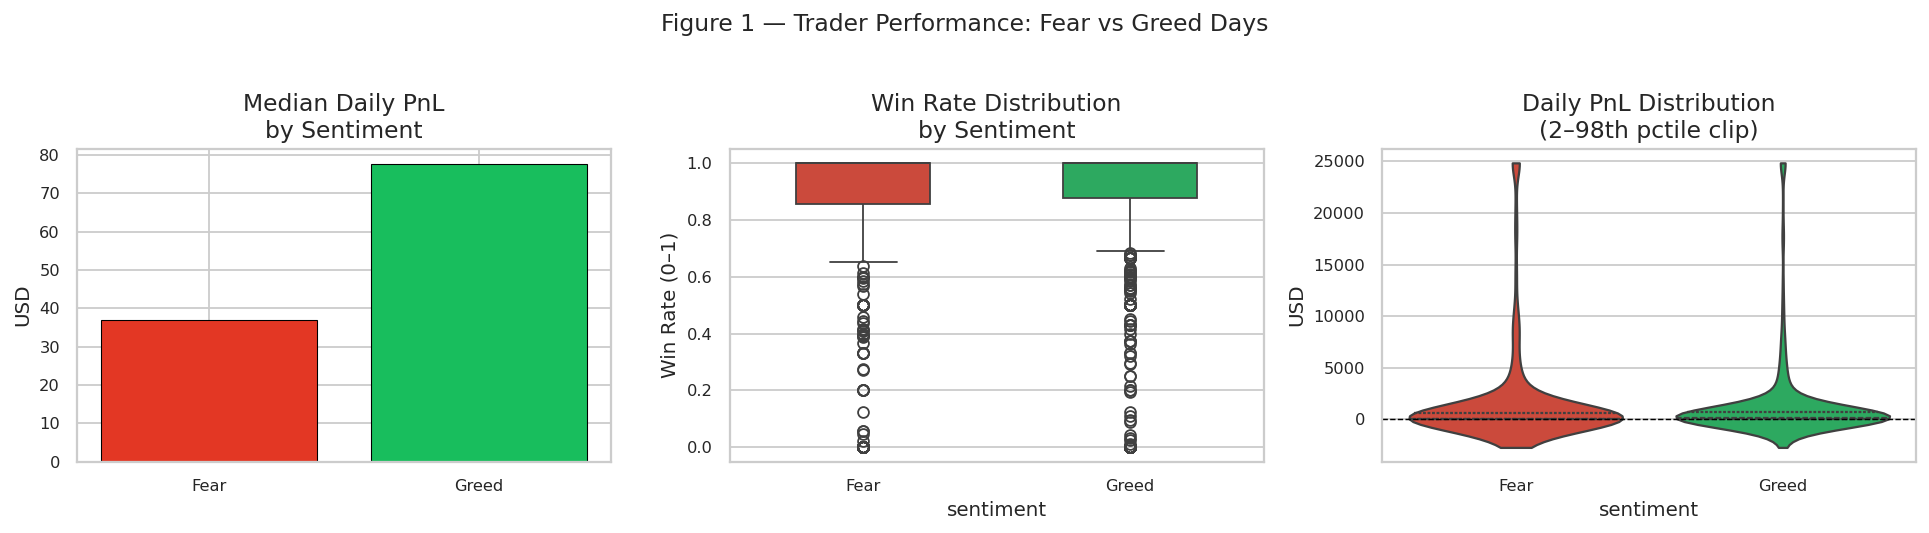

In [267]:
# Visualisation

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# (a) Median daily PnL
med_pnl = fg.groupby('sentiment')['daily_pnl'].median()
axes[0].bar(med_pnl.index, med_pnl.values,
            color=[palette[s] for s in med_pnl.index], edgecolor='black', linewidth=0.6)
axes[0].set_title('Median Daily PnL\nby Sentiment')
axes[0].set_ylabel('USD')
axes[0].axhline(0, color='black', linewidth=0.8, linestyle='--')

# (b) Win rate distribution
sns.boxplot(data=fg, x='sentiment', y='win_rate', palette=palette,
            order=['Fear', 'Greed'], ax=axes[1], width=0.5)
axes[1].set_title('Win Rate Distribution\nby Sentiment')
axes[1].set_ylabel('Win Rate (0–1)')

# (c) PnL violin
fg_clipped = fg.copy()
fg_clipped['daily_pnl'] = fg_clipped['daily_pnl'].clip(
    fg_clipped['daily_pnl'].quantile(0.02),
    fg_clipped['daily_pnl'].quantile(0.98)
)
sns.violinplot(data=fg_clipped, x='sentiment', y='daily_pnl', palette=palette,
               order=['Fear', 'Greed'], ax=axes[2], inner='quartile', cut=0)
axes[2].set_title('Daily PnL Distribution\n(2–98th pctile clip)')
axes[2].set_ylabel('USD')
axes[2].axhline(0, color='black', linewidth=0.8, linestyle='--')

plt.suptitle('Figure 1 — Trader Performance: Fear vs Greed Days', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('fig1_performance_by_sentiment.png', bbox_inches='tight')
plt.show()

Chart A:
Median Daily PnL Bar Chart:
Simply plots the median PnL for Fear vs Greed days. Greed days (~$77) are clearly more profitable for a trader than fear days where the median PnL is usd 37. Median instead of mean as we want to avoid distortion due to outliers.

Chart B:
Win Rate Distribution boxplot: Shows the spread of win rates across all trader-days for each sentiment. Both boxes sit high (0.85–1.0) meaning most traders win most of their trades regardless of sentiment. However, Fear has more outliers scattered low, meaning a subset of traders fall apart on Fear days.

Chart C:
Daily PnL Distribution violin plot: The PnL is clipped to the 2nd–98th percentile first to remove extreme outliers that would squash the shape. The violin's width at any point shows how many traders had that PnL value - both are fat near zero (most traders make small amounts), but Fear's violin stretches much wider upward, confirming more variance/extreme outcomes on Fear days.

Conclusion:
Greed days produce a higher median daily PnL (usd 77.7 vs usd 36.8) with a tighter win rate distribution, suggesting more consistent profitability across traders compared to Fear days.
The wider Fear-day violin confirms greater outcome disparity. While most traders cluster near zero PnL on both regimes, Fear days generate more extreme results in both directions, consistent with the higher standard deviation observed in the summary statistics.


##2. Behavioral Changes Under Fear vs Greed

In [268]:
behavior_cols = ['n_trades', 'long_ratio']
if 'avg_leverage' in fg.columns:
    behavior_cols.append('avg_leverage')
if 'avg_trade_size' in fg.columns:
    behavior_cols.append('avg_trade_size')

behavior_by_sentiment = fg.groupby('sentiment')[behavior_cols].agg(['mean', 'median'])
print('=== Behavior by Sentiment ===')
display(behavior_by_sentiment)

=== Behavior by Sentiment ===


n_trades        long_ratio           avg_trade_size             
                mean median       mean    median           mean       median
sentiment                                                                   
Fear       21.256145    3.0   0.544027  0.538462   10924.904993  2213.306842
Greed      21.221361    2.0   0.478951  0.500000    6450.163608  1912.454286

Traders are equally active on both Fear and Greed days (21 trades per day_ but show a slight long bias or bullish bias on Fear days (54% long) vs. a almost neutral stance on Greed days (48% long). All this while trade sizes are notably larger on Fear days (usd 10,924 mean vs usd 6,450) suggesting traders take bigger but more directionally confused positions when the market is fearful.

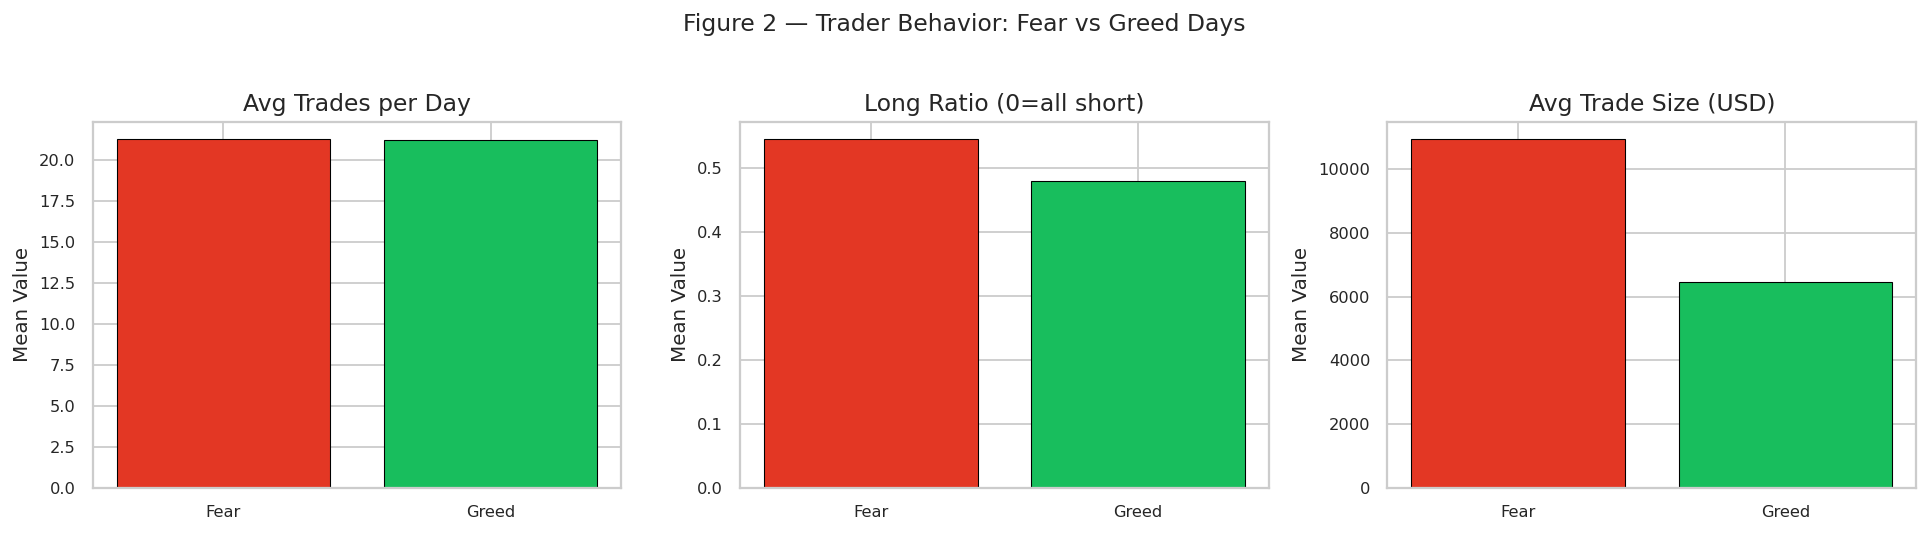

In [269]:
n_plot = len(behavior_cols)
fig, axes = plt.subplots(1, n_plot, figsize=(5 * n_plot, 4))
if n_plot == 1:
    axes = [axes]

titles = {
    'n_trades'       : 'Avg Trades per Day',
    'long_ratio'     : 'Long Ratio (0=all short)',
    'avg_leverage'   : 'Avg Leverage',
    'avg_trade_size' : 'Avg Trade Size (USD)',
}

for ax, col in zip(axes, behavior_cols):
    means = fg.groupby('sentiment')[col].mean()
    ax.bar(means.index, means.values,
           color=[palette[s] for s in means.index], edgecolor='black', linewidth=0.6)
    ax.set_title(titles.get(col, col))
    ax.set_ylabel('Mean Value')

plt.suptitle('Figure 2 — Trader Behavior: Fear vs Greed Days', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('fig2_behavior_by_sentiment.png', bbox_inches='tight')
plt.show()

Interpretation:



*   Trade frequency is virtually identical across Fear and Greed days (~21 trades/day), confirming that sentiment doesn't affect how often traders execute
*   On Fear days traders lean slightly long (54%) while on Greed days they shift closer to neutral (48%), which is counterintuitive as one would expect more bullish positioning during Greed, however the turn of how fear is, is suggesting traders may be hedging or buying dips during fearful periods.
*   The most striking difference is trade size: Fear day positions are ~69% larger (usd 10,924 vs usd 6,450), indicating traders deploy significantly more capital per trade when the market is fearful, possibly attempting to capitalize on perceived dip-buying opportunities but simultaneously taking on more risk.

##3. Segmentation of Traders

###i. Based on Leverage: High vs. Low


In [270]:
if 'mean_leverage' in trader_summary.columns:
    lev_med = trader_summary['mean_leverage'].median()
    trader_summary['leverage_segment'] = np.where(
        trader_summary['mean_leverage'] >= lev_med, 'High Leverage', 'Low Leverage'
    )
    print(f'Leverage median = {lev_med:.1f}x')
    print(trader_summary['leverage_segment'].value_counts())
else:
    # Fallback: segment by trade size
    if 'mean_trade_size' in trader_summary.columns:
        sz_med = trader_summary['mean_trade_size'].median()
        trader_summary['leverage_segment'] = np.where(
            trader_summary['mean_trade_size'] >= sz_med, 'Large Size', 'Small Size'
        )
    print('No leverage column found — segmented by trade size instead.')
    print(trader_summary['leverage_segment'].value_counts())

No leverage column found — segmented by trade size instead.
leverage_segment
Large Size    16
Small Size    16
Name: count, dtype: int64


since the Hyperliquid dataset has no leverage column, the code falls back to splitting traders by their mean trade size at the median, giving 16 large-size and 16 small-size traders out of the 32 total unique traders. ( traders deploying larger position sizes per trade are effectively taking on more risk per trade, similar to high leverage players)

In [271]:
# Merge segment back into daily_trader for sentiment breakdown
daily_trader = daily_trader.merge(
    trader_summary[[ACCOUNT_COL, 'leverage_segment']],
    on=ACCOUNT_COL, how='left'
)
fg = daily_trader[daily_trader['sentiment'].isin(['Fear', 'Greed'])].copy()

seg1_perf = (
    fg.groupby(['leverage_segment', 'sentiment'])[['daily_pnl', 'win_rate']]
    .mean()
    .round(4)
)
print('=== Segment 1: Leverage x Sentiment ===')
display(seg1_perf)

=== Segment 1: Leverage x Sentiment ===


daily_pnl  win_rate
leverage_segment sentiment                     
Large Size       Fear       6337.3000    0.8620
                 Greed      2181.0883    0.9012
Small Size       Fear       1003.1666    0.8405
                 Greed      2725.6558    0.8512

--> Large-size traders are highly sentiment-sensitive.

--> They exploit panic (fear) driven volatility but perform poorer when market is complacent.

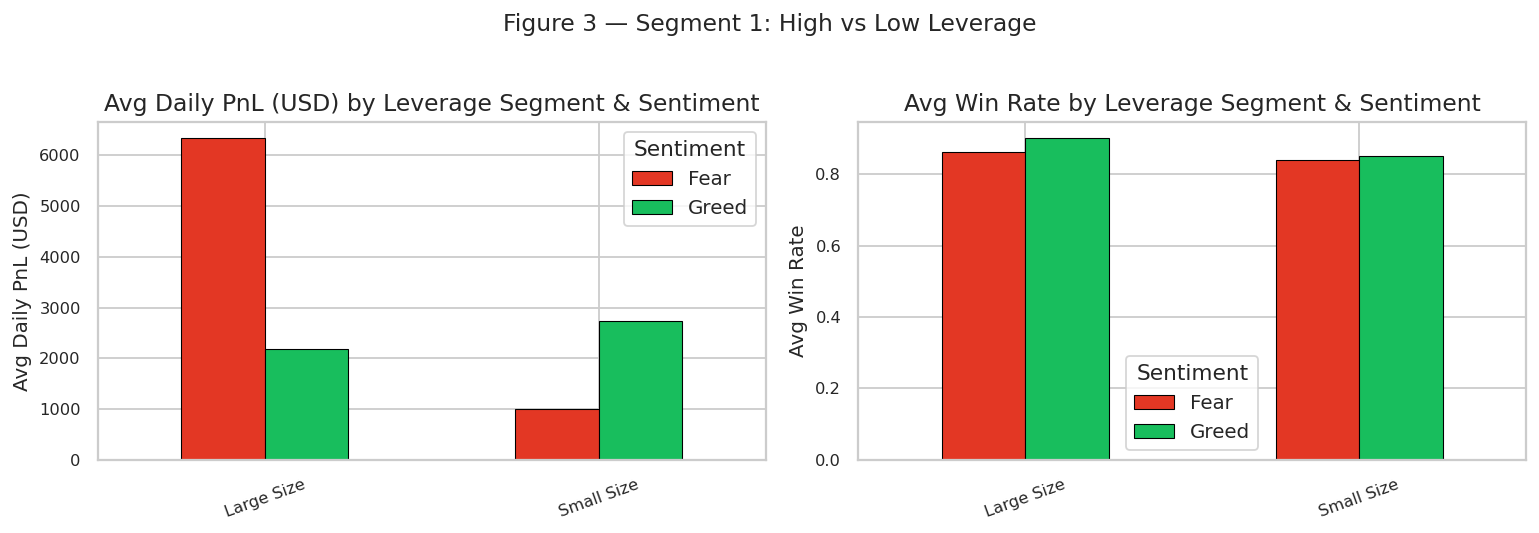

In [272]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, metric, ylabel in zip(axes, ['daily_pnl', 'win_rate'], ['Avg Daily PnL (USD)', 'Avg Win Rate']):
    pivot = seg1_perf[metric].unstack('sentiment')[['Fear', 'Greed']]
    pivot.plot(kind='bar', ax=ax, color=[fearcolor, greedcolor], edgecolor='black', linewidth=0.6)
    ax.set_title(f'{ylabel} by Leverage Segment & Sentiment')
    ax.set_ylabel(ylabel)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=20)
    ax.axhline(0, color='black', linewidth=0.6, linestyle='--')
    ax.legend(title='Sentiment')

plt.suptitle('Figure 3 — Segment 1: High vs Low Leverage', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('fig3_leverage_segment.png', bbox_inches='tight')
plt.show()

--> Large-size traders earn 3x more on Fear days than Greed days

--> small-size traders do the opposite (better on Greed days)

--> and win rates remain high across both segments implying PnL gap is driven by position sizing and volatility capture rather than trade accuracy

###ii. Trade Frequency: Frequent vs Infrequent Traders

In [273]:
freq_med = trader_summary['total_trades'].median()
trader_summary['freq_segment'] = np.where(
    trader_summary['total_trades'] >= freq_med, 'Frequent', 'Infrequent'
)
print(f'Trade count median = {freq_med:.0f}')
print(trader_summary['freq_segment'].value_counts())

daily_trader = daily_trader.merge(
    trader_summary[[ACCOUNT_COL, 'freq_segment']],
    on=ACCOUNT_COL, how='left'
)
fg = daily_trader[daily_trader['sentiment'].isin(['Fear', 'Greed'])].copy()

seg2_perf = (
    fg.groupby(['freq_segment', 'sentiment'])[['daily_pnl', 'win_rate']]
    .mean()
    .round(4)
)
print('\n=== Segment 2: Frequency x Sentiment ===')
display(seg2_perf)

Trade count median = 708
freq_segment
Frequent      16
Infrequent    16
Name: count, dtype: int64

=== Segment 2: Frequency x Sentiment ===


daily_pnl  win_rate
freq_segment sentiment                     
Frequent     Fear       3743.8285    0.8542
             Greed      2771.6041    0.8355
Infrequent   Fear       1457.2831    0.8320
             Greed      2146.0132    0.9454

Frequent traders dominate on Fear days (3.7k usd vs 1.4k usd) while infrequent traders outperform on Greedy days (by a smaller margin)

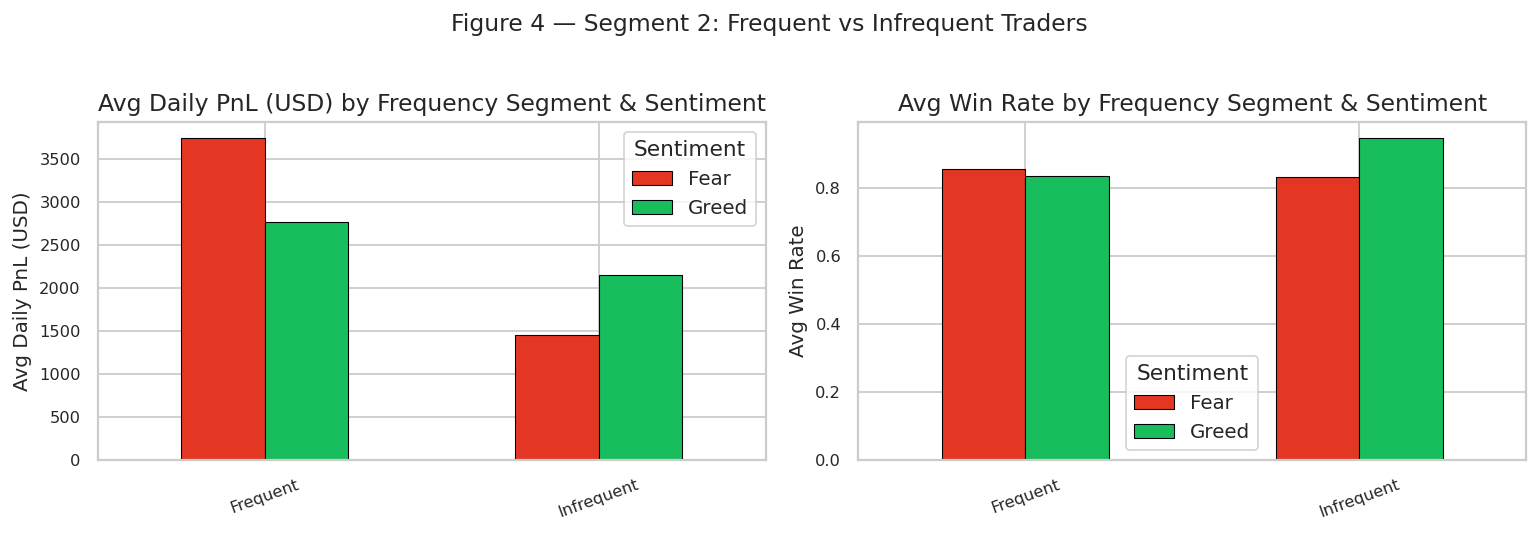

In [274]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, metric, ylabel in zip(axes, ['daily_pnl', 'win_rate'], ['Avg Daily PnL (USD)', 'Avg Win Rate']):
    pivot = seg2_perf[metric].unstack('sentiment')[['Fear', 'Greed']]
    pivot.plot(kind='bar', ax=ax, color=[fearcolor, greedcolor], edgecolor='black', linewidth=0.6)
    ax.set_title(f'{ylabel} by Frequency Segment & Sentiment')
    ax.set_ylabel(ylabel)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=20)
    ax.axhline(0, color='black', linewidth=0.6, linestyle='--')
    ax.legend(title='Sentiment')

plt.suptitle('Figure 4 — Segment 2: Frequent vs Infrequent Traders', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('fig4_frequency_segment.png', bbox_inches='tight')
plt.show()

Infrequent traders show a more notable jump in win rate on Greed days (94.5%) suggesting they are highly selective who wait for trending conditions before entering. While frequent traders grind out profits through volume regardless of sentiment.

###iii. Consistent Winners vs Inconsistent Winners

In [275]:
wr_med  = trader_summary['overall_win_rate'].median()
std_med = trader_summary['pnl_std'].median()

def classify_consistency(row):
    if row['overall_win_rate'] >= wr_med and row['pnl_std'] <= std_med:
        return 'Consistent Winner'
    elif row['overall_win_rate'] < wr_med and row['pnl_std'] > std_med:
        return 'Inconsistent Loser'
    else:
        return 'Mixed'

trader_summary['consistency_segment'] = trader_summary.apply(classify_consistency, axis=1)
print(trader_summary['consistency_segment'].value_counts())

daily_trader = daily_trader.merge(
    trader_summary[[ACCOUNT_COL, 'consistency_segment']],
    on=ACCOUNT_COL, how='left'
)
fg = daily_trader[daily_trader['sentiment'].isin(['Fear', 'Greed'])].copy()

seg3_perf = (
    fg.groupby(['consistency_segment', 'sentiment'])[['daily_pnl', 'win_rate']]
    .mean()
    .round(4)
)
print('\n=== Segment 3: Consistency x Sentiment ===')
display(seg3_perf)

consistency_segment
Mixed                 12
Inconsistent Loser    10
Consistent Winner     10
Name: count, dtype: int64

=== Segment 3: Consistency x Sentiment ===


daily_pnl  win_rate
consistency_segment sentiment                     
Consistent Winner   Fear        392.9001    0.9023
                    Greed      1064.3323    0.9283
Inconsistent Loser  Fear       6484.7515    0.8173
                    Greed      6000.0924    0.7700
Mixed               Fear       2218.1892    0.8303
                    Greed      1466.3744    0.8497

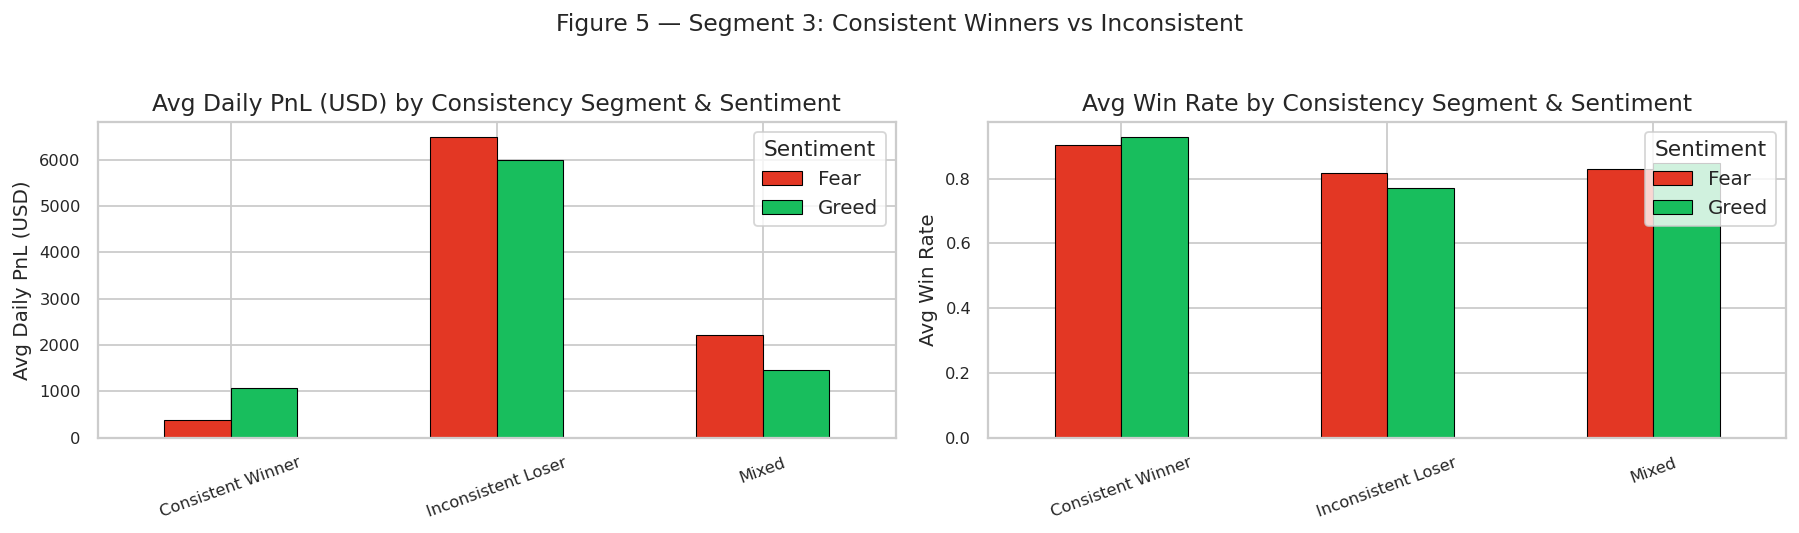

In [276]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, metric, ylabel in zip(axes, ['daily_pnl', 'win_rate'], ['Avg Daily PnL (USD)', 'Avg Win Rate']):
    pivot = seg3_perf[metric].unstack('sentiment')
    for col in ['Fear', 'Greed']:
        if col not in pivot.columns:
            pivot[col] = np.nan
    pivot = pivot[['Fear', 'Greed']]
    pivot.plot(kind='bar', ax=ax, color=[fearcolor, greedcolor], edgecolor='black', linewidth=0.6)
    ax.set_title(f'{ylabel} by Consistency Segment & Sentiment')
    ax.set_ylabel(ylabel)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=20)
    ax.axhline(0, color='black', linewidth=0.6, linestyle='--')
    ax.legend(title='Sentiment')

plt.suptitle('Figure 5 — Segment 3: Consistent Winners vs Inconsistent', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('fig5_consistency_segment.png', bbox_inches='tight')
plt.show()

--> Inconsistent Losers generate the highest PnL despite having the lowest win rates of 77%-82% - implies they are high-risk, large position traders.

--> Consistent Winners show the opposite where they have good win rates but moderate PnL's which implies that they trade small and safe but never risky enough to swing large.

##4. Other Insights

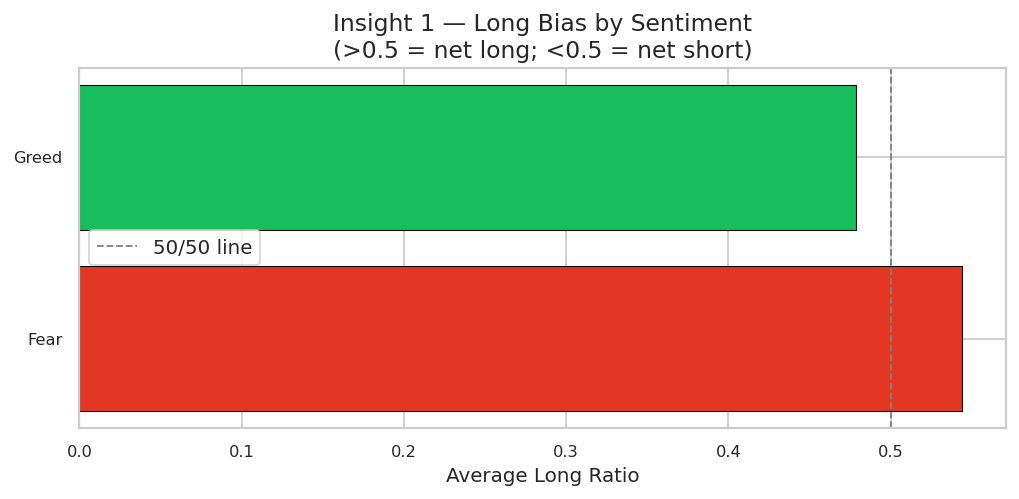

In [277]:
#Insight 1: Long/Short bias shifts with sentiment
fig, ax = plt.subplots(figsize=(8, 4))
long_ratio_by_sent = fg.groupby('sentiment')['long_ratio'].mean()

bars = ax.barh(
    long_ratio_by_sent.index,
    long_ratio_by_sent.values,
    color=[palette[s] for s in long_ratio_by_sent.index],
    edgecolor='black', linewidth=0.6
)
ax.axvline(0.5, color='grey', linestyle='--', linewidth=1, label='50/50 line')
ax.set_xlabel('Average Long Ratio')
ax.set_title('Insight 1 — Long Bias by Sentiment\n(>0.5 = net long; <0.5 = net short)')
ax.legend()
plt.tight_layout()
plt.savefig('fig6_long_bias.png', bbox_inches='tight')
plt.show()

Traders are net long during Fear (54%) and net short during Greed (48%) --> Contrarian dip-buyers (not momentum followers)

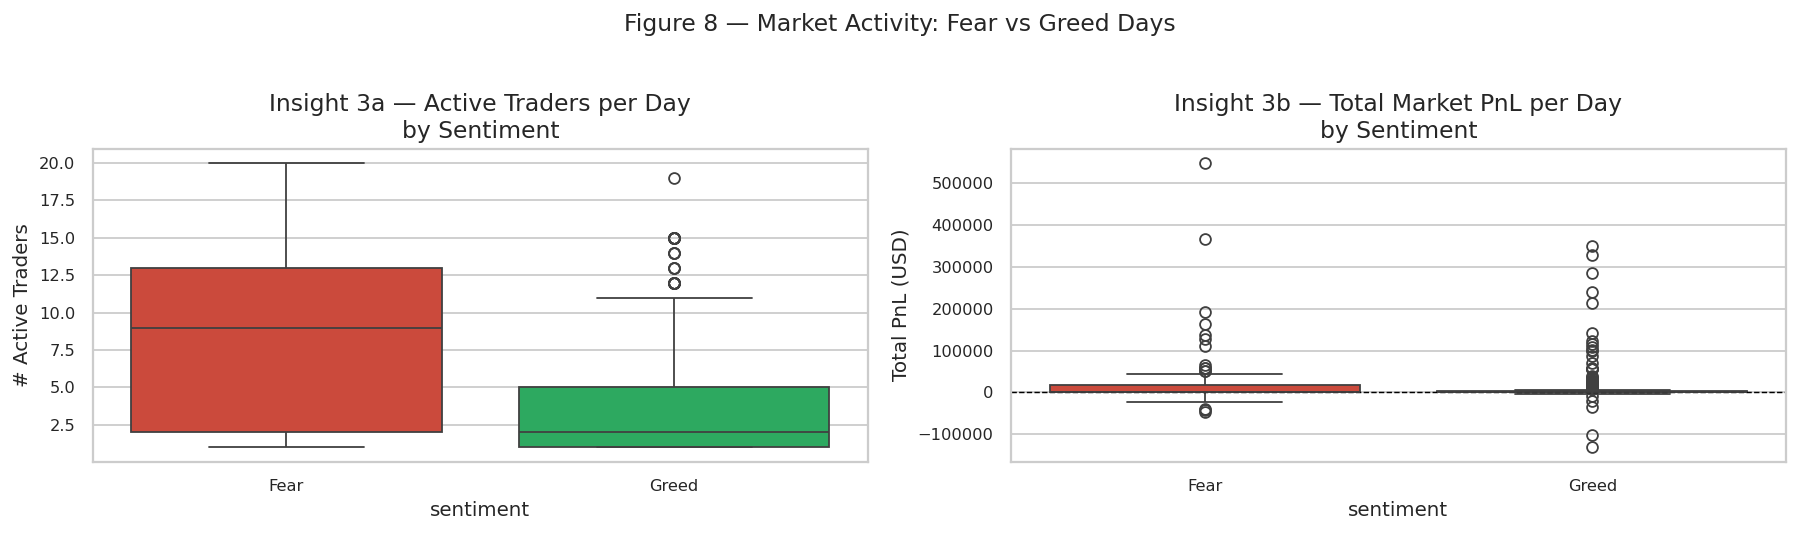

In [279]:
# Insight 2: Trade-day count (market activity) by sentiment
daily_agg = (
    fg.groupby(['date', 'sentiment'])
    .agg(total_traders=('daily_pnl', 'count'),
         total_pnl=('daily_pnl', 'sum'))
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.boxplot(data=daily_agg, x='sentiment', y='total_traders',
            palette=palette, order=['Fear', 'Greed'], ax=axes[0])
axes[0].set_title('Insight 3a — Active Traders per Day\nby Sentiment')
axes[0].set_ylabel('# Active Traders')

sns.boxplot(data=daily_agg, x='sentiment', y='total_pnl',
            palette=palette, order=['Fear', 'Greed'], ax=axes[1])
axes[1].set_title('Insight 3b — Total Market PnL per Day\nby Sentiment')
axes[1].set_ylabel('Total PnL (USD)')
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')

plt.suptitle('Figure 8 — Market Activity: Fear vs Greed Days', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('fig8_market_activity.png', bbox_inches='tight')
plt.show()

Fear days attract significantly more active traders and generate more extreme outlier days and aggregate swings in market PnL than Greed days.

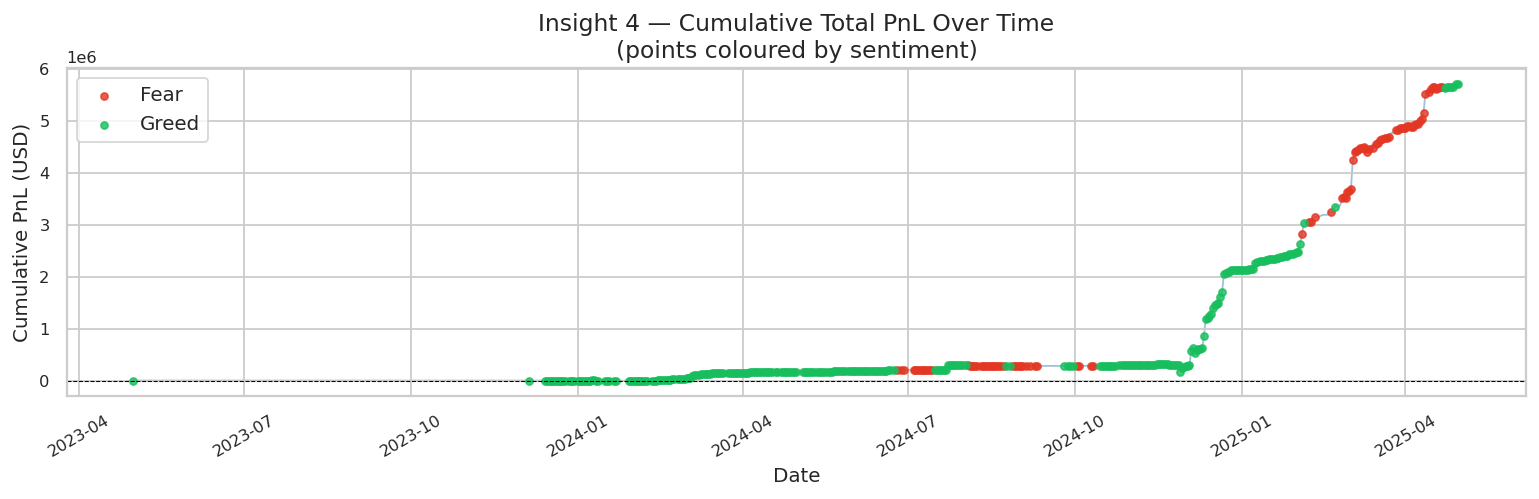

In [280]:
#Insight 3: Cumulative market PnL over time, coloured by sentimen
daily_market = (
    daily_trader
    .groupby(['date', 'sentiment'])
    ['daily_pnl'].sum()
    .reset_index()
    .sort_values('date')
)
daily_market['cum_pnl'] = daily_market['daily_pnl'].cumsum()

fig, ax = plt.subplots(figsize=(12, 4))
for sent, color in palette.items():
    subset = daily_market[daily_market['sentiment'] == sent]
    ax.scatter(subset['date'], subset['cum_pnl'],
               color=color, label=sent, s=15, alpha=0.8)
ax.plot(daily_market['date'], daily_market['cum_pnl'],
        color='steelblue', linewidth=1, alpha=0.5, zorder=0)
ax.set_title('Insight 4 — Cumulative Total PnL Over Time\n(points coloured by sentiment)')
ax.set_ylabel('Cumulative PnL (USD)')
ax.set_xlabel('Date')
ax.axhline(0, color='black', linewidth=0.6, linestyle='--')
ax.legend()
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('fig9_cumulative_pnl.png', bbox_inches='tight')
plt.show()

--> Nearly all cumulative PnL (~usd 6M) was generated in the sharp rally between late 2024 and mid 2025

--> Fear and Greed days contributed almost equally to the climb

--> Overall profitability of this trader cohort is driven by a single concentrated period of market activity rather than steady compounding over time

#Part C: Actionable Strategy Recommendations

In [281]:
# Summary tables to support strategy write-up
print('Performance Summary Table')
summary_table = fg.groupby('sentiment').agg(
    n_trader_days    = ('daily_pnl', 'count'),
    median_pnl       = ('daily_pnl', 'median'),
    mean_win_rate    = ('win_rate',  'mean'),
    mean_long_ratio  = ('long_ratio','mean'),
    mean_n_trades    = ('n_trades',  'mean'),
).round(4)

if 'avg_leverage' in fg.columns:
    summary_table['mean_leverage'] = fg.groupby('sentiment')['avg_leverage'].mean().round(2)
if 'avg_trade_size' in fg.columns:
    summary_table['mean_trade_size'] = fg.groupby('sentiment')['avg_trade_size'].mean().round(2)

display(summary_table)

Performance Summary Table


,n_trader_days,median_pnl,mean_win_rate,mean_long_ratio,mean_n_trades,mean_trade_size
sentiment,,,,,,
Fear,773,36.8000,0.8480,0.544,21.2561,10924.90
Greed,1161,77.7201,0.8639,0.479,21.2214,6450.16
